# NLP 1

### Slang Analaysis

In [1]:
!pip install wordfreq

  Using cached ftfy-6.3.1-py3-none-any.whl.metadata (7.3 kB)
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.4/56.8 MB 7.8 MB/s eta 0:00:08
    --------------------------------------- 0.7/56.8 MB 9.1 MB/s eta 0:00:07
    --------------------------------------- 1.1/56.8 MB 8.4 MB/s eta 0:00:07
    --------------------------------------- 1.4/56.8 MB 8.0 MB/s eta 0:00:07
   - -------------------------------------- 1.8/56.8 MB 8.3 MB/s eta 0:00:07
   - -------------------------------------- 2.1/56.8 MB 7.9 MB/s eta 0:00:07
   - -------------------------------------- 2.4/56.8 MB 8.1 MB/s eta 0:00:07
   - -------------------------------------- 2.8/56.8 MB 7.8 MB/s eta 0:00:07
   -- ------------------------------------- 3.2/56.8 MB 7.9 MB/s eta 0:00:07
   -- ------------------------------------- 3.6/56.8 MB 8.0 MB/s eta 0:00:07
   -- ------------------------------------- 3.9/56.8 MB 7.8 MB/s eta 0:00:07
   --- ---------------

In [3]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordfreq import zipf_frequency

In [7]:
comments = pd.read_csv(r"D:\Social media Assignment 2\comments_cleaned.csv")

comments.head()

,video_id,video_title,author,comment_text,comment_published_at,comment_like_count,clean_comment,comment_length_chars,comment_length_words
0,laZpTO7IFtA,Is 67 just brain rot?,@ExoticNibbles2,Nothing makes me feel older then watching a 15...,2025-10-14T22:24:09Z,7902,nothing makes me feel older then watching a 15...,109,20
1,laZpTO7IFtA,Is 67 just brain rot?,@andrewbunnell7576,6 x 7 = 42 The answer to Life the Universe and...,2025-10-13T20:12:09Z,7692,6 x 7 = 42 the answer to life the universe and...,57,13
2,laZpTO7IFtA,Is 67 just brain rot?,@ColinPaddock,All I know is 6 is afraid of 7.,2025-10-14T06:39:54Z,6194,all i know is 6 is afraid of 7.,31,9
3,laZpTO7IFtA,Is 67 just brain rot?,@codahighland,Having COMPLETELY no context for it before thi...,2025-12-10T16:03:28Z,121,having completely no context for it before thi...,93,18
4,laZpTO7IFtA,Is 67 just brain rot?,@yoberry.,"The next time my kid says ""6-7"", I'm going to ...",2025-10-18T07:29:08Z,2084,"the next time my kid says ""6-7"", i'm going to ...",88,18


In [9]:
minimal_stopwords = {
    "the", "and", "is", "a", "an", "to", "of", "in", "it", "that", "this",
    "for", "on", "with", "as", "are", "was", "be", "but", "or", "so",
    "if", "at", "by", "from", "you", "your", "we", "they", "he", "she",
    "i", "me", "my", "our", "their", "his", "her", "them", "its", "not",
    "do", "does", "did", "have", "has", "had", "can", "will", "would",
    "should", "could", "just", "like", "get", "got"
}

all_tokens = []

for comment in comments["clean_comment"]:
    tokens = re.findall(r"\b[a-zA-Z][a-zA-Z0-9_']*\b", str(comment))

    for token in tokens:
        token = token.lower().strip()

        if token not in minimal_stopwords and len(token) > 2:
            all_tokens.append(token)

print("Total tokens:", len(all_tokens))
print("Unique tokens:", len(set(all_tokens)))

Total tokens: 111049
Unique tokens: 12312


In [11]:
token_counts = Counter(all_tokens)

word_freq_df = pd.DataFrame(
    token_counts.items(),
    columns=["term", "frequency"]
).sort_values(by="frequency", ascending=False)

word_freq_df.head(30)

,term,frequency
7,video,1113
20,all,709
31,time,708
68,what,704
118,when,701
155,about,672
34,i'm,658
495,more,630
209,how,611
213,it's,599


In [13]:
MIN_FREQUENCY = 5

frequent_words = word_freq_df[
    word_freq_df["frequency"] >= MIN_FREQUENCY
].copy()

frequent_words.shape

(2957, 2)

In [15]:
def is_slang_candidate(term):
    standard_english_score = zipf_frequency(term, "en")

    # keep words that are uncommon in standard English
    if standard_english_score < 3.5:
        return True

    return False


frequent_words["standard_english_score"] = frequent_words["term"].apply(
    lambda x: zipf_frequency(x, "en")
)

slang_candidates = frequent_words[
    frequent_words["term"].apply(is_slang_candidate)
].copy()

slang_candidates = slang_candidates.sort_values(
    by=["frequency", "standard_english_score"],
    ascending=[False, True]
)

slang_candidates.head(50)

,term,frequency,standard_english_score
132,brainrot,320,0.00
4364,scrolling,174,3.48
537,skibidi,159,0.00
874,tiktok,106,2.46
7517,slop,70,2.71
4223,reels,62,3.12
1300,dopamine,56,3.37
582,didn,54,3.29
3370,yeet,49,2.51
3425,rowan,45,3.32


In [17]:
slang_candidates.to_csv("slang_candidates.csv", index=False)

print("Saved as slang_candidates.csv")

Saved as slang_candidates.csv


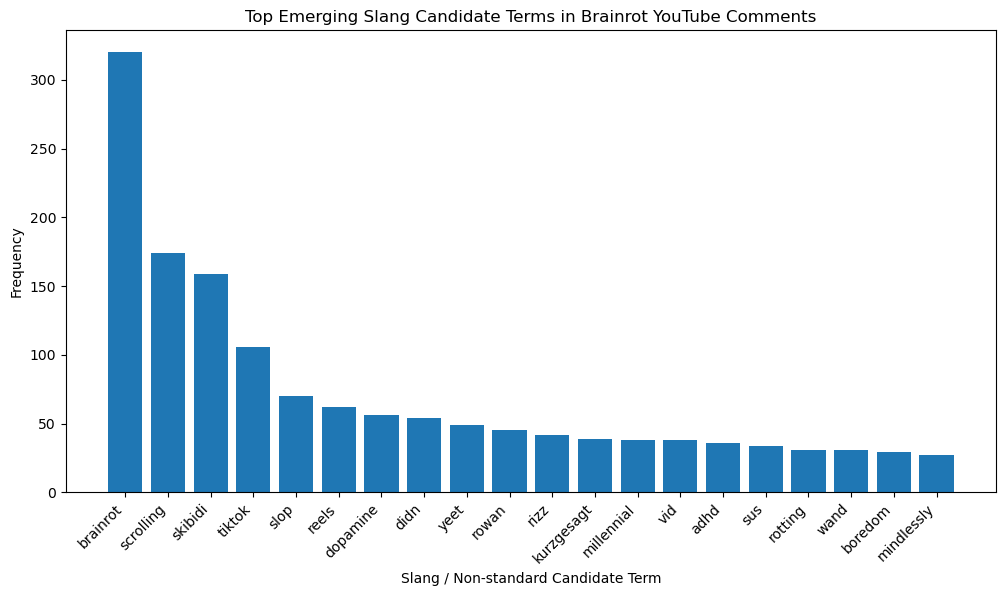

In [28]:
top_slang = slang_candidates.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_slang["term"], top_slang["frequency"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Slang / Non-standard Candidate Term")
plt.ylabel("Frequency")
plt.title("Top Emerging Slang Candidate Terms in Brainrot YouTube Comments")
plt.show()

# Thematic Slang Categorisation

In [31]:
slang_df = pd.read_csv("slang_candidates.csv")

slang_df.head()

,term,frequency,standard_english_score
0,brainrot,320,0.00
1,scrolling,174,3.48
2,skibidi,159,0.00
3,tiktok,106,2.46
4,slop,70,2.71


In [33]:
noise_terms = {
    "rowan",
    "kurzgesagt",
    "aevy",
    "howtown",
    "josephine",
    "lacan",
    "wand",
    "achina",
    "shinn",
    "weil",
    "eminem",
    "gangnam",
    "mera",
    "bhai"
}

slang_df = slang_df[
    ~slang_df["term"].isin(noise_terms)
].copy()

print("Remaining terms:", len(slang_df))

Remaining terms: 200


In [35]:
category_mapping = {

    # Meme / ironic Gen Z slang
    "skibidi": "meme_slang",
    "rizz": "meme_slang",
    "gyatt": "meme_slang",
    "gyat": "meme_slang",
    "rizzler": "meme_slang",
    "sigma": "meme_slang",
    "yeet": "meme_slang",
    "sus": "meme_slang",
    "sheesh": "meme_slang",
    "bussin": "meme_slang",
    "finna": "meme_slang",
    "slay": "meme_slang",
    "goated": "meme_slang",
    "delulu": "meme_slang",
    "npc": "meme_slang",
    "irl": "meme_slang",
    "ngl": "meme_slang",
    "yall": "meme_slang",
    "imma": "meme_slang",
    "hella": "meme_slang",

    # Brainrot / irony culture
    "brainrot": "brainrot_irony",
    "brainrotted": "brainrot_irony",
    "braincells": "brainrot_irony",
    "doomscrolling": "brainrot_irony",
    "rotting": "brainrot_irony",
    "rotted": "brainrot_irony",
    "rots": "brainrot_irony",
    "mindlessly": "brainrot_irony",
    "mindless": "brainrot_irony",
    "overstimulation": "brainrot_irony",
    "overstimulated": "brainrot_irony",

    # Platform addiction / social media consumption
    "scrolling": "platform_addiction",
    "tiktok": "platform_addiction",
    "tiktoks": "platform_addiction",
    "reels": "platform_addiction",
    "dopamine": "platform_addiction",
    "algorithmic": "platform_addiction",
    "swiping": "platform_addiction",
    "screentime": "platform_addiction",
    "shorts": "platform_addiction",
    "scrolling": "platform_addiction",

    # Cognitive / attention concerns
    "adhd": "cognitive_effects",
    "boredom": "cognitive_effects",
    "distractions": "cognitive_effects",
    "rewired": "cognitive_effects",
    "cognitively": "cognitive_effects",
    "focus": "cognitive_effects",
    "gratification": "cognitive_effects",
    "detox": "cognitive_effects",
    "subconscious": "cognitive_effects",
    "intellect": "cognitive_effects",

    # Generational identity / internet generation
    "genz": "generational_identity",
    "millennial": "generational_identity",
    "millenial": "generational_identity",
    "millenials": "generational_identity",
    "boomers": "generational_identity",
    "boomer": "generational_identity",
    "alphas": "generational_identity",
    "genx": "generational_identity",
    "ipads": "generational_identity",
    "ipadkid": "generational_identity"
}

In [38]:
slang_df["category"] = slang_df["term"].map(category_mapping)

categorized_df = slang_df.dropna(subset=["category"]).copy()

categorized_df.head(20)

,term,frequency,standard_english_score,category
0,brainrot,320,0.00,brainrot_irony
1,scrolling,174,3.48,platform_addiction
2,skibidi,159,0.00,meme_slang
3,tiktok,106,2.46,platform_addiction
5,reels,62,3.12,platform_addiction
6,dopamine,56,3.37,platform_addiction
8,yeet,49,2.51,meme_slang
10,rizz,42,1.81,meme_slang
12,millennial,38,3.33,generational_identity
14,adhd,36,3.49,cognitive_effects


In [40]:
category_frequency = categorized_df.groupby("category")["frequency"].sum().reset_index()

category_frequency = category_frequency.sort_values(
    by="frequency",
    ascending=False
)

category_frequency

,category,frequency
0,brainrot_irony,476
4,platform_addiction,426
3,meme_slang,424
2,generational_identity,129
1,cognitive_effects,120


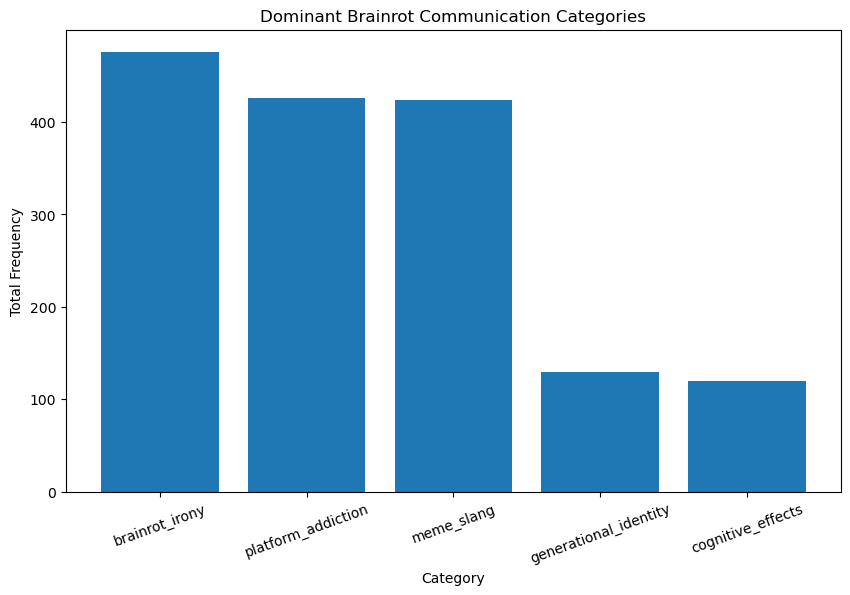

In [42]:
plt.figure(figsize=(10,6))

plt.bar(
    category_frequency["category"],
    category_frequency["frequency"]
)

plt.title("Dominant Brainrot Communication Categories")

plt.xlabel("Category")
plt.ylabel("Total Frequency")

plt.xticks(rotation=20)

plt.show()